数据集形状：(20640, 8)
特征名称：['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
房价范围：[0.15, 5.00]万美元

开始训练普通线性回归模型...
迭代第0次，损失值：2.8149
迭代第100次，损失值：0.6520
迭代第200次，损失值：0.3561
迭代第300次，损失值：0.3096
迭代第400次，损失值：0.2977
迭代第500次，损失值：0.2914
迭代第600次，损失值：0.2866
迭代第700次，损失值：0.2826
迭代第800次，损失值：0.2792
迭代第900次，损失值：0.2763

模型评估结果：
训练集MSE：0.5477
测试集MSE：0.5672
训练集R²：0.5903
测试集R²：0.5672


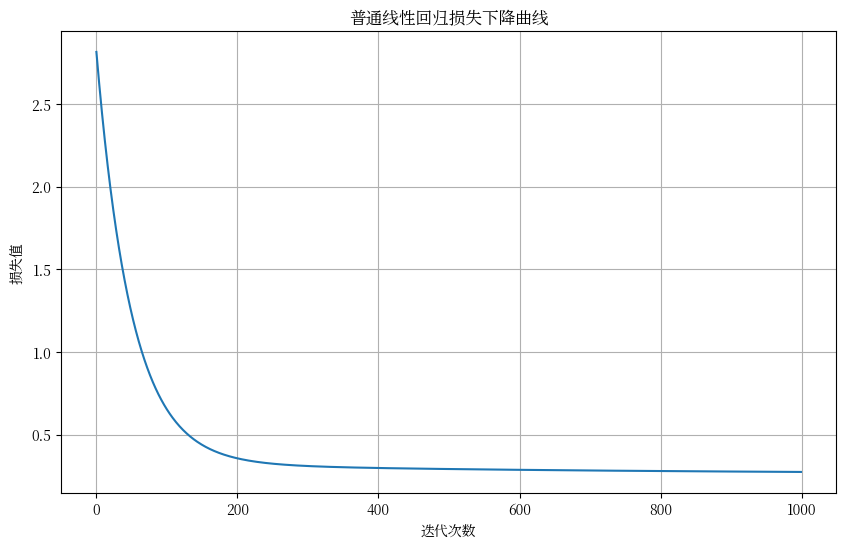

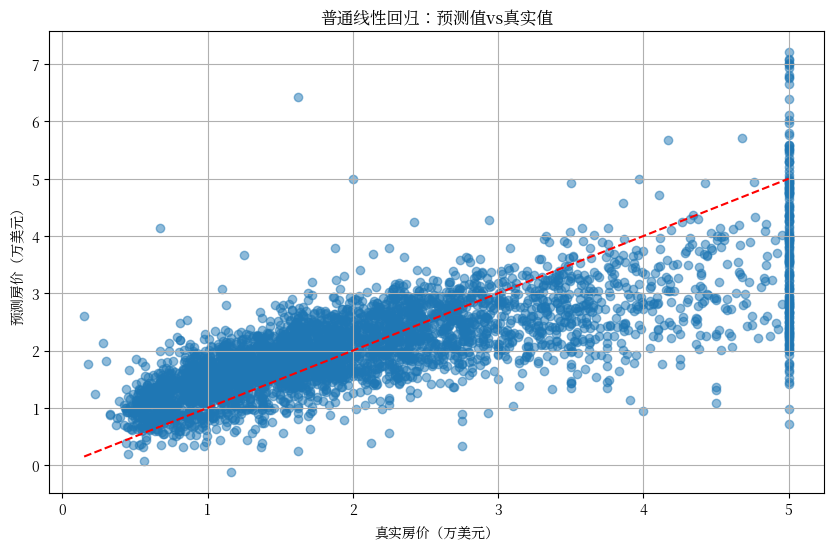

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Serif CJK JP']        # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False          # 用来正常显示负号
from sklearn.datasets import fetch_california_housing # 加州房价数据集
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # 特征标准化
from sklearn.metrics import mean_squared_error, r2_score  # 回归评估指标

# 线性回归类
class MyLinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        初始化线性回归模型
        :param learning_rate: 学习率，控制梯度下降的步长
        :param n_iterations: 迭代次数
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None  # 权重向量w
        self.bias = None  # 偏置项b
        self.loss_history = []  # 记录每次迭代的损失值

    def fit(self, X, y):
        """
        训练模型（梯度下降法）
        :param X: 训练特征矩阵，形状(m, n)，m个样本，n个特征
        :param y: 训练标签，形状(m,)
        """
        m, n = X.shape  # m=样本数，n=特征数
        
        # 初始化权重和偏置为0
        self.weights = np.zeros(n)
        self.bias = 0

        # 梯度下降迭代
        for i in range(self.n_iterations):
            # 1. 预测值：y_pred = X·w + b
            y_pred = np.dot(X, self.weights) + self.bias

            # 2. 计算损失（均方误差）
            loss = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.loss_history.append(loss)

            # 3. 计算梯度
            dw = (1/m) * np.dot(X.T, (y_pred - y))  # 权重的梯度
            db = (1/m) * np.sum(y_pred - y)  # 偏置的梯度

            # 4. 更新权重和偏置
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # 每100次迭代打印一次损失
            if i % 100 == 0:
                print(f"迭代第{i}次，损失值：{loss:.4f}")

    def predict(self, X):
        """
        用训练好的模型进行预测
        :param X: 测试特征矩阵
        :return: 预测值
        """
        return np.dot(X, self.weights) + self.bias

# 1. 加载并预处理加州房价数据集
# 加载数据集（第一次运行会自动下载）
california = fetch_california_housing()
X = california.data
y = california.target

print(f"数据集形状：{X.shape}")
print(f"特征名称：{california.feature_names}")
print(f"房价范围：[{y.min():.2f}, {y.max():.2f}]万美元")

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 特征标准化（梯度下降法必须做，否则收敛极慢甚至不收敛）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 训练自己的线性回归模型
print("\n开始训练普通线性回归模型...")
model = MyLinearRegression(learning_rate=0.01, n_iterations=1000)
model.fit(X_train_scaled, y_train)

# 3. 模型预测与评估
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# 计算评估指标
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n模型评估结果：")
print(f"训练集MSE：{train_mse:.4f}")
print(f"测试集MSE：{test_mse:.4f}")
print(f"训练集R²：{train_r2:.4f}")
print(f"测试集R²：{test_r2:.4f}")

# 绘制损失下降曲线
plt.figure(figsize=(10, 6))
plt.plot(model.loss_history)
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.title('普通线性回归损失下降曲线')
plt.grid(True)
plt.show()

# 绘制预测值vs真实值散点图
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 理想预测线
plt.xlabel('真实房价（万美元）')
plt.ylabel('预测房价（万美元）')
plt.title('普通线性回归：预测值vs真实值')
plt.grid(True)
plt.show()